In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import cartopy.crs as ccrs
import cmocean
import seaborn as sns
from scipy.stats import pearsonr 
from scipy.stats import shapiro 
from scipy.stats import linregress 
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from OceanDataStore import OceanDataCatalog 
from nemo_cookbook import NEMODataTree  
from matplotlib.patches import Rectangle
import statsmodels.api as sm

C:\Users\TomAH\anaconda3\envs\new_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['legend.fontsize'] = 18

In [2]:
def select_by_lonlat(ds, lon_target, lat_target):
    lat = ds['gphit'].values
    lon = ds['glamt'].values
    distance = np.sqrt((lat - lat_target)**2 + (lon - lon_target)**2)
    y_idx, x_idx = np.unravel_index(np.argmin(distance), distance.shape)
    print('x index =', x_idx)
    print('y index =', y_idx)
    return (y_idx, x_idx)


In [3]:
salinity = xr. open_dataset('salinity_ts.nc')['sos_abs']
MLD_annual = xr.open_dataset('MLD_ts_0.25.nc')['somxl010']
salinity['year'] = salinity['time_counter'].dt.year
MLD_annual['year'] = MLD_annual['time_counter'].dt.year

In [7]:
catalog = OceanDataCatalog(catalog_name='noc-stac')
catalog.search(collection='noc-npd-era5', standard_name='sea_surface_temperature')
ds_monthly = catalog.open_dataset(id=catalog.Items[3].id,
                          start_datetime='1990-01',
                          end_datetime='2024-12')

catalog.search(collection='noc-npd-era5', item_name='domain_cfg')
config = catalog.open_dataset(id=catalog.Items[1].id)

# Merge into a data tree
datasets_monthly = {'parent': {'domain': config, 'gridT': ds_monthly}}
dt_global_monthly = NEMODataTree.from_datasets(datasets = datasets_monthly)

# Clip to North Atlantic 
bbox = (-85.0, 0.0, 0.0, 80.0)
dt_monthly = dt_global_monthly.clip_grid(grid='gridT', bbox=bbox)

# Convert to datasets
ds = (dt_monthly['gridT']).dataset


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/gn/T1y
              Title: T1y Icechunk repository
              Description: **Annual mean global ocean physics outputs defined at NEMO model T-points.**

**OceanDataCatalog Access:**
`catalog.open_dataset(id='noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/gn/T1y')`
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/gn/T1m
              Title: T1m Icechunk repository
              Description: **Monthly mean global ocean physics outputs defined at NEMO model T-points.**

**OceanDataCatalog Access:**
`catalog.open_dataset(id='noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/gn/T1m')`
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca025-era5v1/r1i1c1f1/gn/T1y_3d
       

In [8]:
MLD_Sep = ds['somxl010'].where(ds['time_counter'].dt.month ==  9, drop = True)
MLD_Feb = ds['somxl010'].where(ds['time_counter'].dt.month == 2, drop = True)
MLD_Sep['year'] = MLD_Sep['time_counter'].dt.year
MLD_Feb['year'] = MLD_Feb['time_counter'].dt.year 


In [9]:
salinity_Sep = ds['sos_abs'].where(ds['time_counter'].dt.month ==  9, drop = True)
salinity_Feb = ds['sos_abs'].where(ds['time_counter'].dt.month == 2, drop = True)
salinity_Sep['year'] = salinity_Sep['time_counter'].dt.year
salinity_Feb['year'] = salinity_Feb['time_counter'].dt.year 


1


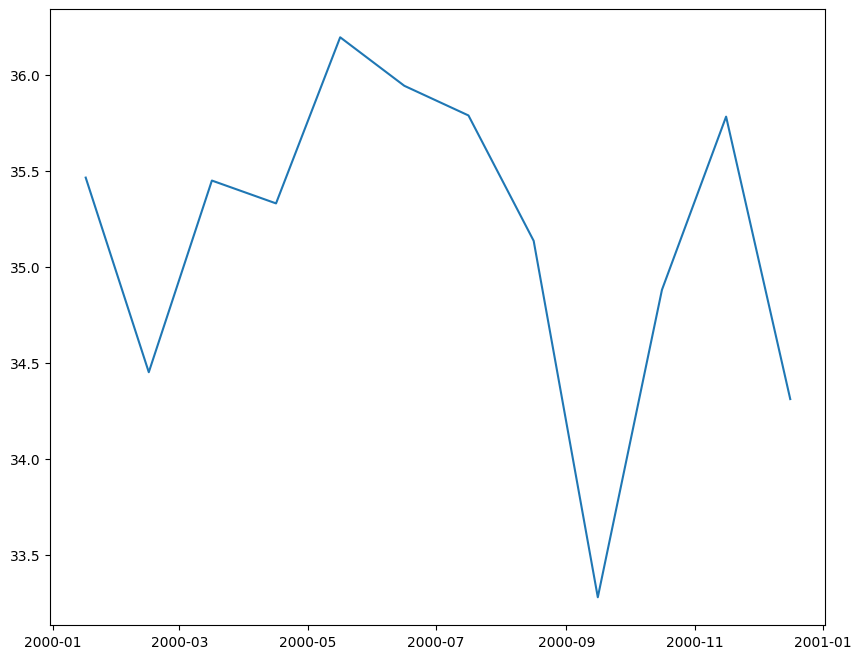

In [46]:
salinity_2000 = ds['sos_abs'].where(ds['time_counter'].dt.year == 2000, drop = True)
point = salinity_2000.isel(j = 187, i = 101)
print(1)
fig, ax  = plt.subplots(figsize =  (10, 8))
ax.plot(point['time_counter'], point)


In [52]:
salinity_Sep.isel(j = 187, i = 101, time_counter = 11).values

array([[      nan, 34.009758, 33.99018 , ..., 35.67284 , 35.672493,
        35.67144 ],
       [      nan, 33.985043, 33.9669  , ..., 35.649815, 35.650917,
        35.652973],
       [      nan, 33.949593, 33.934914, ..., 35.637733, 35.637596,
        35.63851 ],
       ...,
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan]], shape=(482, 341), dtype=float32)

x index = 200
y index = 20


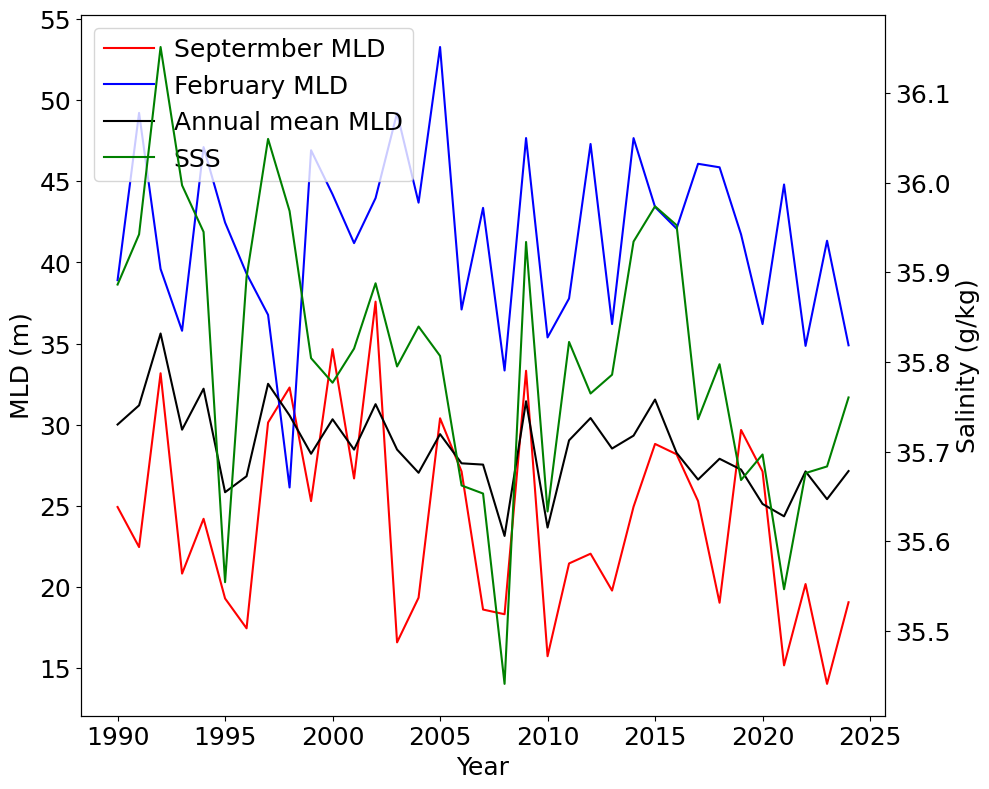

In [33]:
## Consider 35W, 5N (Central Subtropical Ocean)

j_idx, i_idx = select_by_lonlat(salinity, -35.0, 5.0)

fig, ax = plt.subplots(figsize = (10, 8))

ax0 = ax
ax1 = ax0.twinx()
l1 = ax0.plot(MLD_Sep['year'], MLD_Sep.isel(j = j_idx, i = i_idx), color = 'r', label = 'Septermber MLD')
l2 = ax0.plot(MLD_Feb['year'], MLD_Feb.isel(j = j_idx, i = i_idx), color = 'b', label = 'February MLD')
l3 = ax0.plot(MLD_annual['year'], MLD_annual.isel(j = j_idx, i = i_idx), color = 'k', label = 'Annual mean MLD')
l4 = ax1.plot(salinity['year'], salinity.isel(j = j_idx, i = i_idx), color = 'g', label = 'SSS')
lines = l1 + l2 + l3 + l4 
labels = [l.get_label() for l in lines]

ax0.set_xlabel('Year')
ax0.set_ylabel('MLD (m)')
ax1.set_ylabel('Salinity (g/kg)')
ax0.legend(lines, labels, loc = 'upper left')

plt.tight_layout()
plt.show()

x index = 80
y index = 61


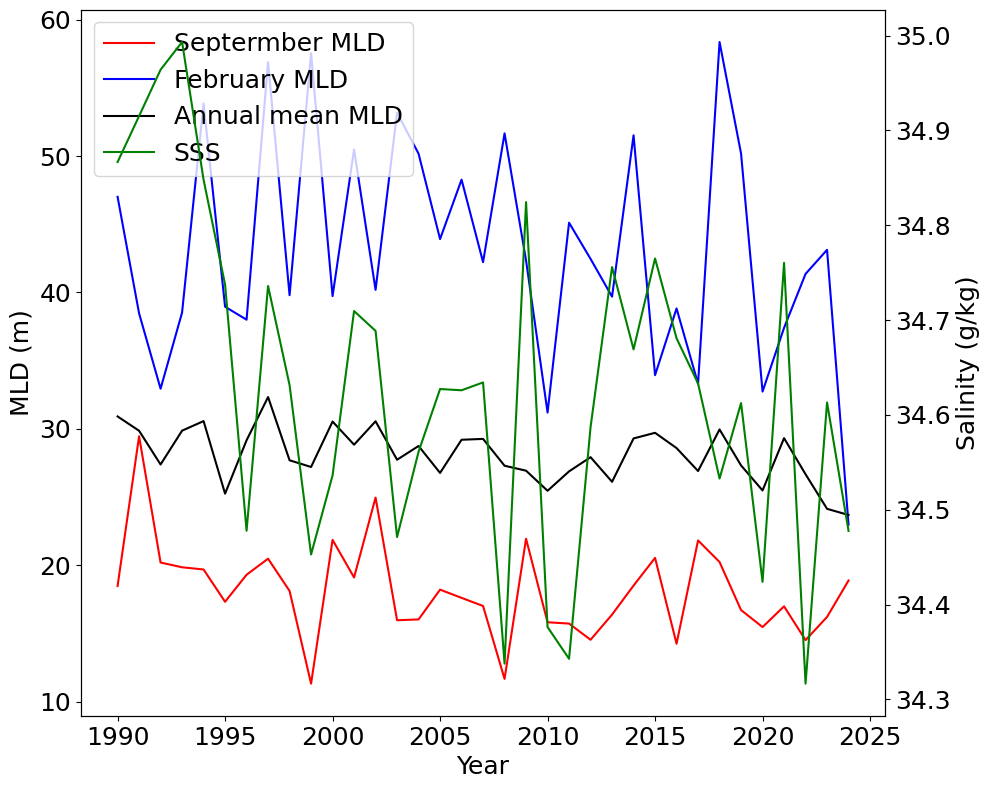

In [34]:
## Consider 65W, 15N (Western Subtropical Ocean)

j_idx, i_idx = select_by_lonlat(salinity, -65.0, 15.0)

fig, ax = plt.subplots(figsize = (10, 8))

ax0 = ax
ax1 = ax0.twinx()
l1 = ax0.plot(MLD_Sep['year'], MLD_Sep.isel(j = j_idx, i = i_idx), color = 'r', label = 'Septermber MLD')
l2 = ax0.plot(MLD_Feb['year'], MLD_Feb.isel(j = j_idx, i = i_idx), color = 'b', label = 'February MLD')
l3 = ax0.plot(MLD_annual['year'], MLD_annual.isel(j = j_idx, i = i_idx), color = 'k', label = 'Annual mean MLD')
l4 = ax1.plot(salinity['year'], salinity.isel(j = j_idx, i = i_idx), color = 'g', label = 'SSS')
lines = l1 + l2 + l3 + l4 
labels = [l.get_label() for l in lines]

ax0.set_xlabel('Year')
ax0.set_ylabel('MLD (m)')
ax1.set_ylabel('Salinity (g/kg)')
ax0.legend(lines, labels, loc = 'upper left')

plt.tight_layout()
plt.show()

x index = 101
y index = 187


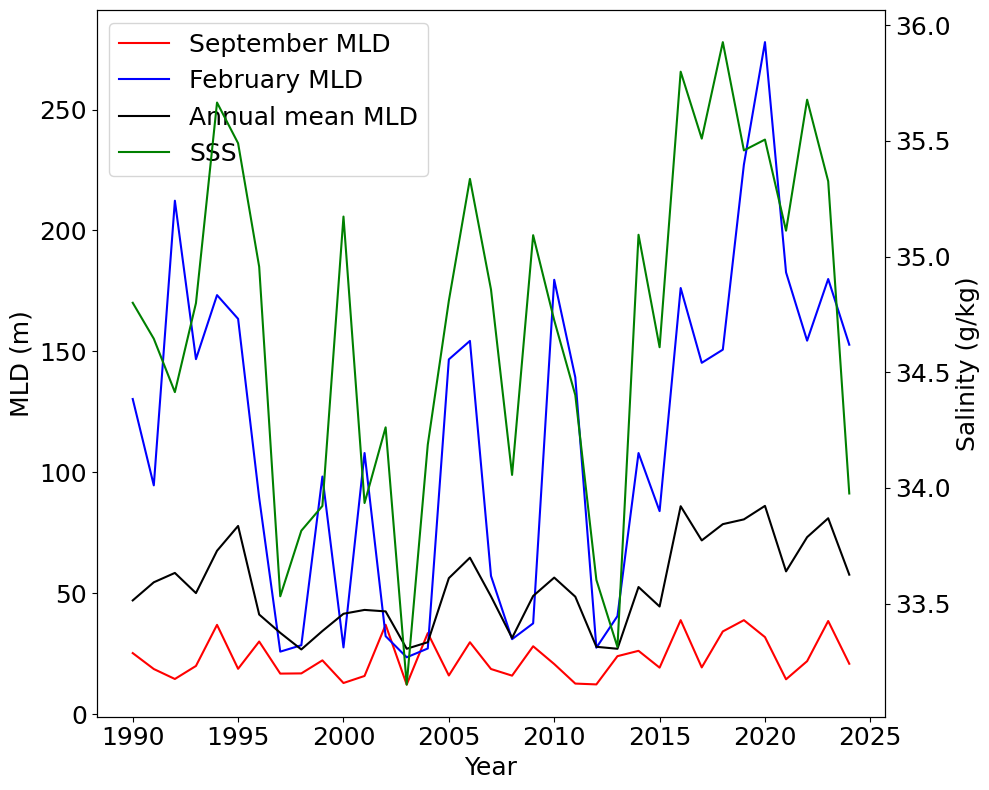

In [37]:
## Consider 60W, 42N (GUlf Stream)

j_idx, i_idx = select_by_lonlat(salinity, -60.0, 42.0)

fig, ax = plt.subplots(figsize = (10, 8))

ax0 = ax
ax1 = ax0.twinx()
l1 = ax0.plot(MLD_Sep['year'], MLD_Sep.isel(j = j_idx, i = i_idx), color = 'r', label = 'September MLD')
l2 = ax0.plot(MLD_Feb['year'], MLD_Feb.isel(j = j_idx, i = i_idx), color = 'b', label = 'February MLD')
l3 = ax0.plot(MLD_annual['year'], MLD_annual.isel(j = j_idx, i = i_idx), color = 'k', label = 'Annual mean MLD')
l4 = ax1.plot(salinity['year'], salinity.isel(j = j_idx, i = i_idx), color = 'g', label = 'SSS')
lines = l1 + l2 + l3 + l4 
labels = [l.get_label() for l in lines]

ax0.set_xlabel('Year')
ax0.set_ylabel('MLD (m)')
ax1.set_ylabel('Salinity (g/kg)')
ax0.legend(lines, labels, loc = 'upper left')

plt.tight_layout()
plt.show()

x index = 221
y index = 258


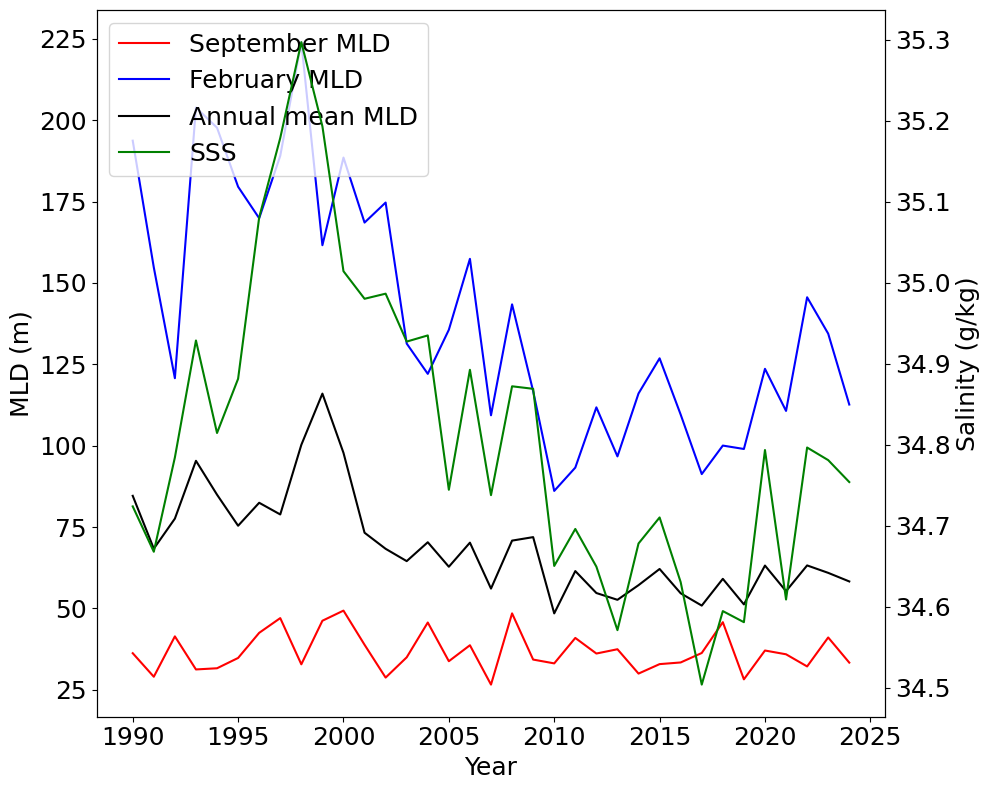

In [38]:
## Consider 30W, 55N (NAWH)

j_idx, i_idx = select_by_lonlat(salinity, -30.0, 55.0)

fig, ax = plt.subplots(figsize = (10, 8))

ax0 = ax
ax1 = ax0.twinx()
l1 = ax0.plot(MLD_Sep['year'], MLD_Sep.isel(j = j_idx, i = i_idx), color = 'r', label = 'September MLD')
l2 = ax0.plot(MLD_Feb['year'], MLD_Feb.isel(j = j_idx, i = i_idx), color = 'b', label = 'February MLD')
l3 = ax0.plot(MLD_annual['year'], MLD_annual.isel(j = j_idx, i = i_idx), color = 'k', label = 'Annual mean MLD')
l4 = ax1.plot(salinity['year'], salinity.isel(j = j_idx, i = i_idx), color = 'g', label = 'SSS')
lines = l1 + l2 + l3 + l4 
labels = [l.get_label() for l in lines]

ax0.set_xlabel('Year')
ax0.set_ylabel('MLD (m)')
ax1.set_ylabel('Salinity (g/kg)')
ax0.legend(lines, labels, loc = 'upper left')

plt.tight_layout()
plt.show()

x index = 148
y index = 377


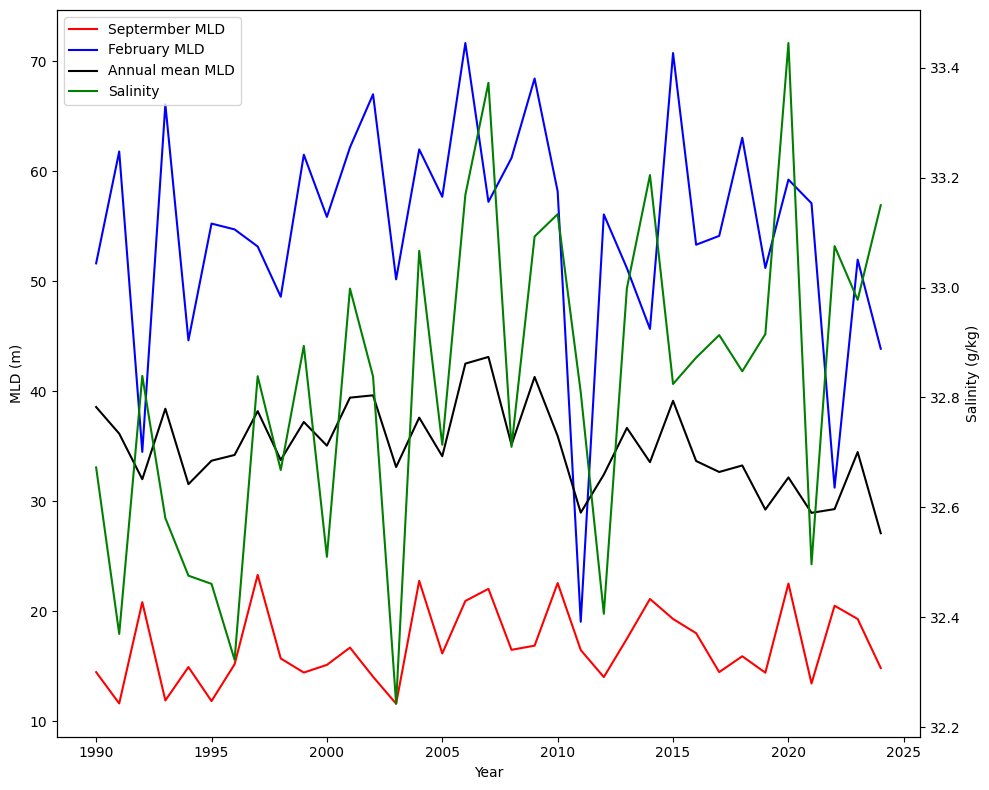

In [36]:
## Consider 58W, 70N (Ice Edge - not dat relevant)

j_idx, i_idx = select_by_lonlat(salinity, -58.0, 70.0)

fig, ax = plt.subplots(figsize = (10, 8))

ax0 = ax
ax1 = ax0.twinx()
l1 = ax0.plot(MLD_Sep['year'], MLD_Sep.isel(j = j_idx, i = i_idx), color = 'r', label = 'Septermber MLD')
l2 = ax0.plot(MLD_Feb['year'], MLD_Feb.isel(j = j_idx, i = i_idx), color = 'b', label = 'February MLD')
l3 = ax0.plot(MLD_annual['year'], MLD_annual.isel(j = j_idx, i = i_idx), color = 'k', label = 'Annual mean MLD')
l4 = ax1.plot(salinity['year'], salinity.isel(j = j_idx, i = i_idx), color = 'g', label = 'Salinity')
lines = l1 + l2 + l3 + l4
labels = [l.get_label() for l in lines]

ax0.set_xlabel('Year')
ax0.set_ylabel('MLD (m)')
ax1.set_ylabel('Salinity (g/kg)')
ax0.legend(lines, labels, loc = 'upper left')

plt.tight_layout()
plt.show()

x index = 160
y index = 126


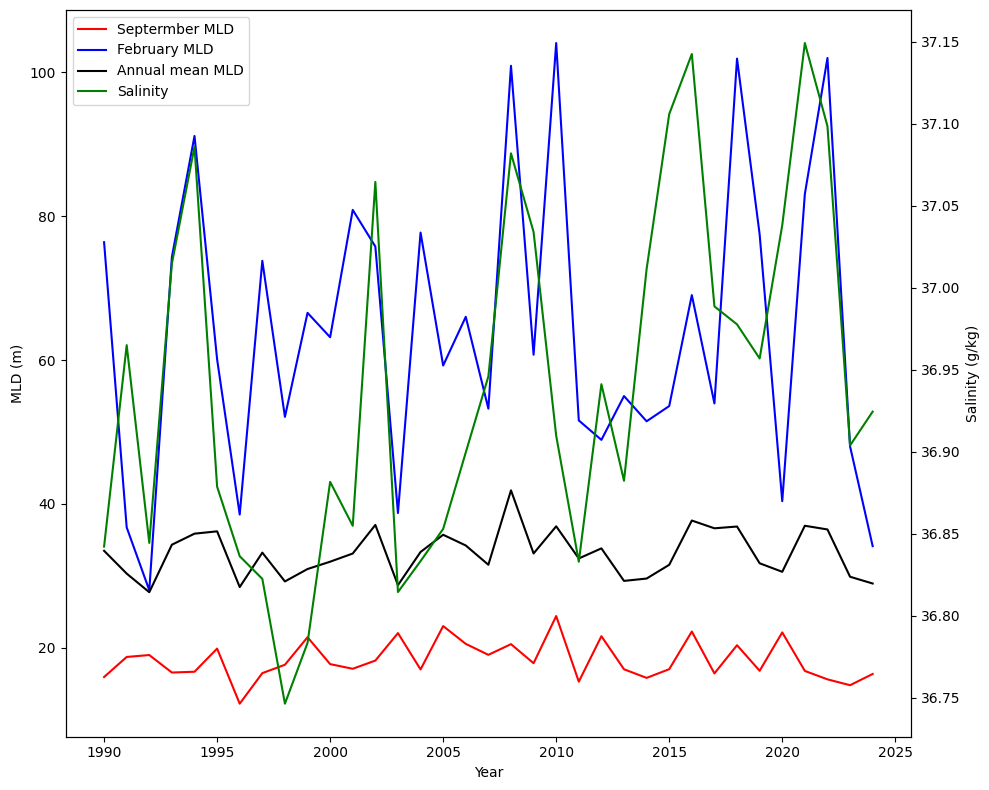

In [37]:
## Consider 45W, 30N 

j_idx, i_idx = select_by_lonlat(salinity, -45.0, 30.0)

fig, ax = plt.subplots(figsize = (10, 8))

ax0 = ax
ax1 = ax0.twinx()
l1 = ax0.plot(MLD_Sep['year'], MLD_Sep.isel(j = j_idx, i = i_idx), color = 'r', label = 'Septermber MLD')
l2 = ax0.plot(MLD_Feb['year'], MLD_Feb.isel(j = j_idx, i = i_idx), color = 'b', label = 'February MLD')
l3 = ax0.plot(MLD_annual['year'], MLD_annual.isel(j = j_idx, i = i_idx), color = 'k', label = 'Annual mean MLD')
l4 = ax1.plot(salinity['year'], salinity.isel(j = j_idx, i = i_idx), color = 'g', label = 'Salinity')
lines = l1 + l2 + l3 + l4
labels = [l.get_label() for l in lines]

ax0.set_xlabel('Year')
ax0.set_ylabel('MLD (m)')
ax1.set_ylabel('Salinity (g/kg)')
ax0.legend(lines, labels, loc = 'upper left')

plt.tight_layout()
plt.show()

x index = 260
y index = 99


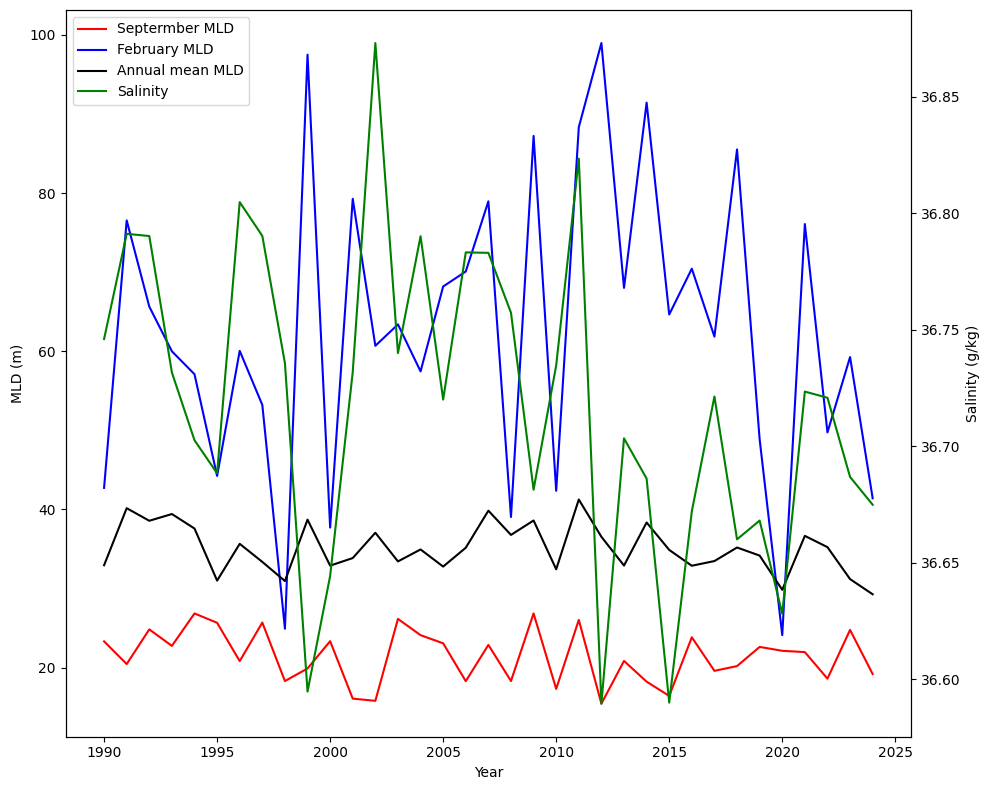

In [38]:
## Consider 20W, 24N S

j_idx, i_idx = select_by_lonlat(salinity, -20.0, 24.0)

fig, ax = plt.subplots(figsize = (10, 8))

ax0 = ax
ax1 = ax0.twinx()
l1 = ax0.plot(MLD_Sep['year'], MLD_Sep.isel(j = j_idx, i = i_idx), color = 'r', label = 'Septermber MLD')
l2 = ax0.plot(MLD_Feb['year'], MLD_Feb.isel(j = j_idx, i = i_idx), color = 'b', label = 'February MLD')
l3 = ax0.plot(MLD_annual['year'], MLD_annual.isel(j = j_idx, i = i_idx), color = 'k', label = 'Annual mean MLD')
l4 = ax1.plot(salinity['year'], salinity.isel(j = j_idx, i = i_idx), color = 'g', label = 'Salinity')
lines = l1 + l2 + l3 + l4
labels = [l.get_label() for l in lines]

ax0.set_xlabel('Year')
ax0.set_ylabel('MLD (m)')
ax1.set_ylabel('Salinity (g/kg)')
ax0.legend(lines, labels, loc = 'upper left')

plt.tight_layout()
plt.show()

x index = 140
y index = 103


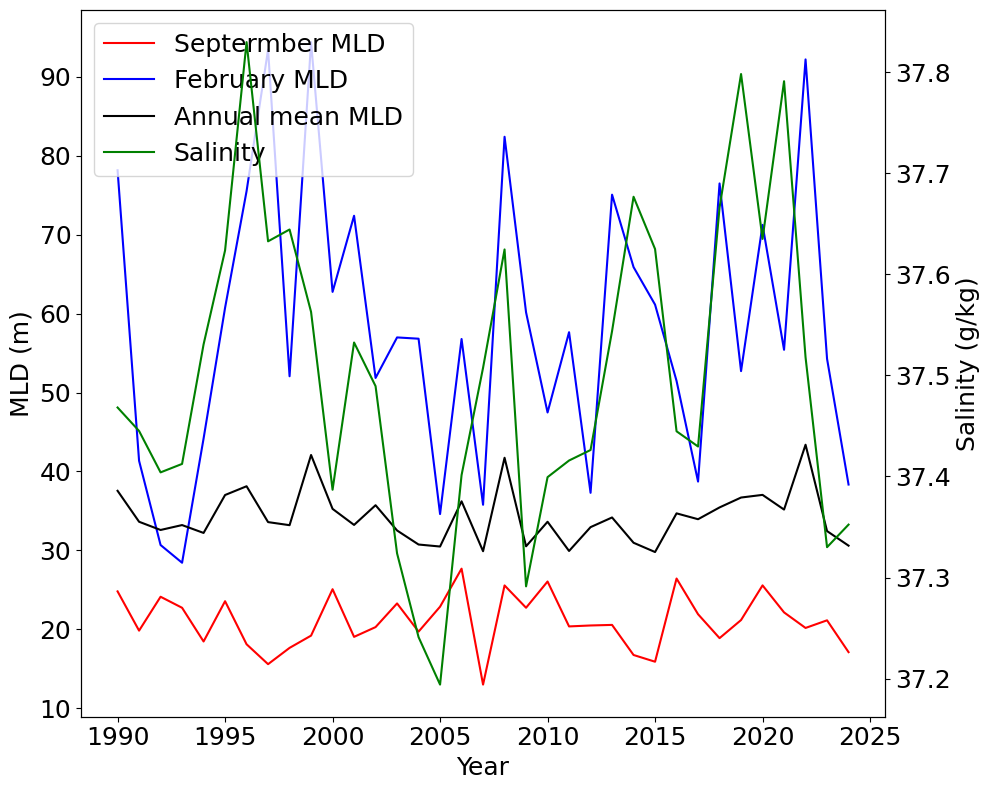

In [30]:
## Consider 50W, 25N S

j_idx, i_idx = select_by_lonlat(salinity, -50.0, 25.0)

fig, ax = plt.subplots(figsize = (10, 8))

ax0 = ax
ax1 = ax0.twinx()
l1 = ax0.plot(MLD_Sep['year'], MLD_Sep.isel(j = j_idx, i = i_idx), color = 'r', label = 'Septermber MLD')
l2 = ax0.plot(MLD_Feb['year'], MLD_Feb.isel(j = j_idx, i = i_idx), color = 'b', label = 'February MLD')
l3 = ax0.plot(MLD_annual['year'], MLD_annual.isel(j = j_idx, i = i_idx), color = 'k', label = 'Annual mean MLD')
l4 = ax1.plot(salinity['year'], salinity.isel(j = j_idx, i = i_idx), color = 'g', label = 'Salinity')
lines = l1 + l2 + l3 + l4
labels = [l.get_label() for l in lines]

ax0.set_xlabel('Year')
ax0.set_ylabel('MLD (m)')
ax1.set_ylabel('Salinity (g/kg)')
ax0.legend(lines, labels, loc = 'upper left')

plt.tight_layout()
plt.show()

x index = 286
y index = 327


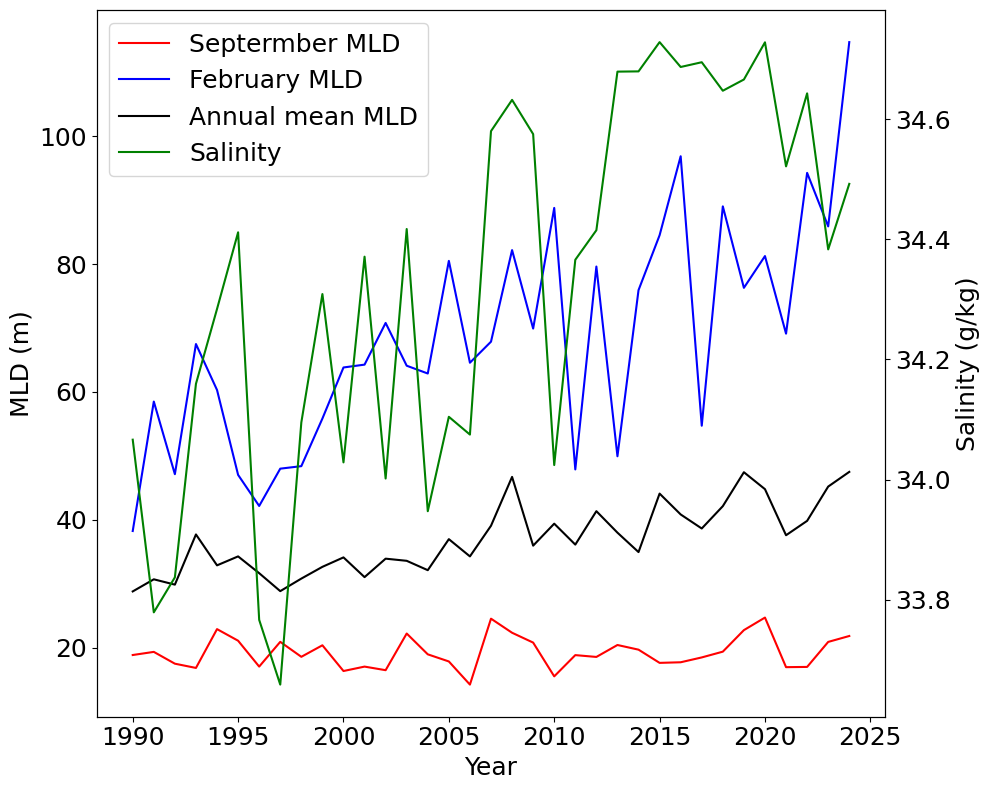

In [32]:
## Consider 10W, 65N S

j_idx, i_idx = select_by_lonlat(salinity, -10.0, 65.0)

fig, ax = plt.subplots(figsize = (10, 8))

ax0 = ax
ax1 = ax0.twinx()
l1 = ax0.plot(MLD_Sep['year'], MLD_Sep.isel(j = j_idx, i = i_idx), color = 'r', label = 'Septermber MLD')
l2 = ax0.plot(MLD_Feb['year'], MLD_Feb.isel(j = j_idx, i = i_idx), color = 'b', label = 'February MLD')
l3 = ax0.plot(MLD_annual['year'], MLD_annual.isel(j = j_idx, i = i_idx), color = 'k', label = 'Annual mean MLD')
l4 = ax1.plot(salinity['year'], salinity.isel(j = j_idx, i = i_idx), color = 'g', label = 'Salinity')
lines = l1 + l2 + l3 + l4
labels = [l.get_label() for l in lines]

ax0.set_xlabel('Year')
ax0.set_ylabel('MLD (m)')
ax1.set_ylabel('Salinity (g/kg)')
ax0.legend(lines, labels, loc = 'upper left')

plt.tight_layout()
plt.show()